# Análisis de Series Temporales
## Trabajo Final - Maestría en Ciencias de Datos
### Predicción de Cortes de Energía con SVR

**Materia:** Análisis de Series de Tiempo  
**Alumnos:** Arenas - Banegas - Marín - Zamora

---

## Resumen Ejecutivo

Este trabajo presenta un análisis predictivo de **cortes de energía eléctrica** utilizando Prophet. El dataset incluye:

- **Cortes:** Cantidad semanal de cortes de luz
- **Temp:** Temperatura media semanal (°C) — variable exógena
- **Hum:** Humedad relativa media semanal (%) — variable exógena

Se analiza la relación entre temperatura, humedad y cortes de luz para desarrollar un modelo predictivo.

# 1. Marco teórico: SVR

SVR es una extensión del algoritmo de clasificación SVM al problema de regresión. En lugar de encontrar un hiperplano que separe clases, busca una función que aproxime los valores objetivo dentro de un margen de tolerancia ε, penalizando únicamente los errores que superan dicho umbral.

la serie temporal se reformula como un problema supervisado mediante variables rezagadas. Los hiperparámetros C, gamma y epsilon se optimizan mediante GridSearchCV con validación cruzada temporal (TimeSeriesSplit), respetando el orden cronológico de los datos.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
SEED      = 42
TEST_FRAC = 0.20
N_LAGS    = 4


## 2. Configuración inicial

Se evalúan modelos univariados para las tres series (Cortes, Temp y Hum) y un modelo multivariado donde Temp y Hum actúan como variables explicativas de Cortes. En todos los casos se utilizan los últimos 4 valores observados (n_lags=4) como features, y el split es 80/20 consistente con el resto del trabajo.
La búsqueda de hiperparámetros cubre 48 combinaciones: valores de regularización C ∈ {0.1, 1, 10, 100}, parámetros de kernel gamma ∈ {scale, auto, 0.01, 0.1} y márgenes de tolerancia epsilon ∈ {0.1, 0.5, 1.0}. La selección se realiza mediante GridSearchCV con TimeSeriesSplit de 5 pliegues, garantizando que en cada fold el modelo nunca entrena con datos posteriores a los de validación.

In [ ]:
PARAM_GRID = {
    'C'      : [0.1, 1, 10, 100],
    'gamma'  : ['scale', 'auto', 0.01, 0.1],
    'epsilon': [0.1, 0.5, 1.0],
    'kernel' : ['rbf'],
}

In [ ]:
np.random.seed(SEED)

In [ ]:
df = pd.read_csv('completo.csv', parse_dates=['Semana'], index_col='Semana')
for col in ['Temp', 'Hum']:
    if df[col].dtype == object:
        df[col] = df[col].str.replace(',', '.', regex=False).astype(float)
df = df.asfreq('W-SUN').sort_index()

N       = len(df)
N_TRAIN = int(N * (1 - TEST_FRAC))
N_TEST  = N - N_TRAIN

train_df = df.iloc[:N_TRAIN]
test_df  = df.iloc[N_TRAIN:]
print(f"Train: {N_TRAIN} | Test: {N_TEST}")

Train: 209 | Test: 53


In [ ]:

# ── Helpers ──────────────────────────────────────────────────
def make_lags(arr, n_lags):
    X, y = [], []
    for i in range(n_lags, len(arr)):
        X.append(arr[i - n_lags:i])
        y.append(arr[i])
    return np.array(X), np.array(y)

def make_lags_multi(target, *exogs, n_lags):
    X, y = [], []
    for i in range(n_lags, len(target)):
        row = list(target[i - n_lags:i])
        for ex in exogs:
            row += list(ex[i - n_lags:i])
        X.append(row)
        y.append(target[i])
    return np.array(X), np.array(y)

def fit_svr(X_train_s, y_train_s):
    tscv = TimeSeriesSplit(n_splits=5)
    gs   = GridSearchCV(SVR(), PARAM_GRID, cv=tscv,
                        scoring='neg_root_mean_squared_error',
                        n_jobs=-1, verbose=0)
    gs.fit(X_train_s, y_train_s)
    print(f"    Params: {gs.best_params_}")
    return gs.best_estimator_

def predict_recursive(model, seed_window_s, n_steps, scaler_y, n_lags):
    window  = list(seed_window_s)
    preds_s = []
    for _ in range(n_steps):
        x    = np.array(window[-n_lags:]).reshape(1, -1)
        pred = model.predict(x)[0]
        preds_s.append(pred)
        window.append(pred)
    return scaler_y.inverse_transform(
               np.array(preds_s).reshape(-1, 1)).ravel()

def predict_recursive_multi(model, seed_s, n_steps, scaler_y, n_lags, n_feat):
    window  = list(seed_s)
    preds_s = []
    for _ in range(n_steps):
        x    = np.array(window[:n_feat]).reshape(1, -1)
        pred = model.predict(x)[0]
        preds_s.append(pred)
        window = [pred] + window[:n_lags - 1] + window[n_lags:]
    return scaler_y.inverse_transform(
               np.array(preds_s).reshape(-1, 1)).ravel()

# Almacén
svr_results = []

## 3. Modelado Univariado

Cada serie se modela de forma independiente utilizando únicamente su propia historia. A partir de los últimos 4 valores observados se construye la ventana de entrada, y el modelo predice recursivamente los N_TEST pasos del período de test: en cada paso, la predicción generada se incorpora como input para el siguiente, propagando la información hacia adelante sin utilizar valores reales del test.
Las series se estandarizan antes del entrenamiento y las predicciones se llevan de vuelta a la escala original para calcular las métricas.


▶ Cortes
    Params: {'C': 100, 'epsilon': 0.5, 'gamma': 0.01, 'kernel': 'rbf'}
    RMSE=7.9810  MAE=5.4937

▶ Temp
    Params: {'C': 10, 'epsilon': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}
    RMSE=7.6638  MAE=6.2515

▶ Hum
    Params: {'C': 10, 'epsilon': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}
    RMSE=16.0349  MAE=14.0264


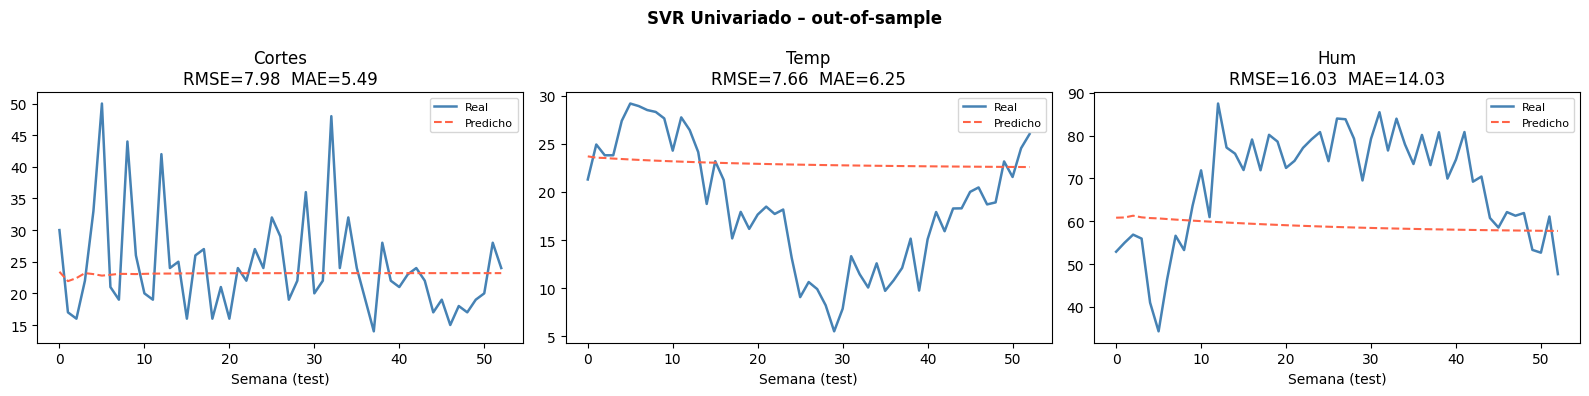

In [ ]:
SERIES = {
    'Cortes': df['Cortes'].values.astype(float),
    'Temp'  : df['Temp'].values.astype(float),
    'Hum'   : df['Hum'].values.astype(float),
}

for nombre, arr in SERIES.items():
    print(f"\n▶ {nombre}")

    y_train = arr[:N_TRAIN]
    y_test  = arr[N_TRAIN:]

    X_tr, y_tr = make_lags(y_train, N_LAGS)

    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    X_tr_s   = scaler_X.fit_transform(X_tr)
    y_tr_s   = scaler_y.fit_transform(y_tr.reshape(-1, 1)).ravel()

    best = fit_svr(X_tr_s, y_tr_s)

    seed_s = scaler_X.transform(y_train[-N_LAGS:].reshape(1, -1))[0]
    y_pred = predict_recursive(best, seed_s, N_TEST, scaler_y, N_LAGS)

    rmse_val = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    mae_val  = float(mean_absolute_error(y_test, y_pred))
    print(f"    RMSE={rmse_val:.4f}  MAE={mae_val:.4f}")

    svr_results.append({
        'model' : 'SVR_Uni',
        'serie' : nombre,
        'date'  : test_df.index,
        'y_true': y_test,
        'y_pred': y_pred,
        'rmse'  : round(rmse_val, 4),
        'mae'   : round(mae_val, 4),
    })

# Gráfico univariado
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('SVR Univariado – out-of-sample', fontweight='bold')
for ax, r in zip(axes, svr_results[:3]):
    ax.plot(r['y_true'], label='Real',     color='steelblue', lw=1.8)
    ax.plot(r['y_pred'], label='Predicho', color='tomato',    lw=1.5, linestyle='--')
    ax.set_title(f'{r["serie"]}\nRMSE={r["rmse"]:.2f}  MAE={r["mae"]:.2f}')
    ax.set_xlabel('Semana (test)')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('svr_univariado.png', dpi=120, bbox_inches='tight')
plt.show()

Los tres modelos seleccionaron gamma=0.01, lo que indica que el kernel RBF requiere un radio de influencia amplio para generalizar bien con series semanales de baja densidad muestral. Para Cortes, el GridSearch favoreció una regularización alta (C=100), permitiendo mayor flexibilidad para ajustarse a la variabilidad de la serie.

## 4. Modelado Multivariado

En el enfoque multivariado, los rezagos de Temp y Hum se incorporan como features adicionales junto con los rezagos de Cortes, con la hipótesis de que las condiciones climáticas aportan información predictiva sobre los eventos de corte. El vector de entrada pasa de 4 features (solo lags de Cortes) a 12 features (4 lags × 3 variables), y el modelo predice recursivamente Cortes actualizando únicamente los lags de la variable objetivo en cada paso.

    Params: {'C': 10, 'epsilon': 0.5, 'gamma': 0.1, 'kernel': 'rbf'}
  RMSE=8.5993  MAE=5.6620


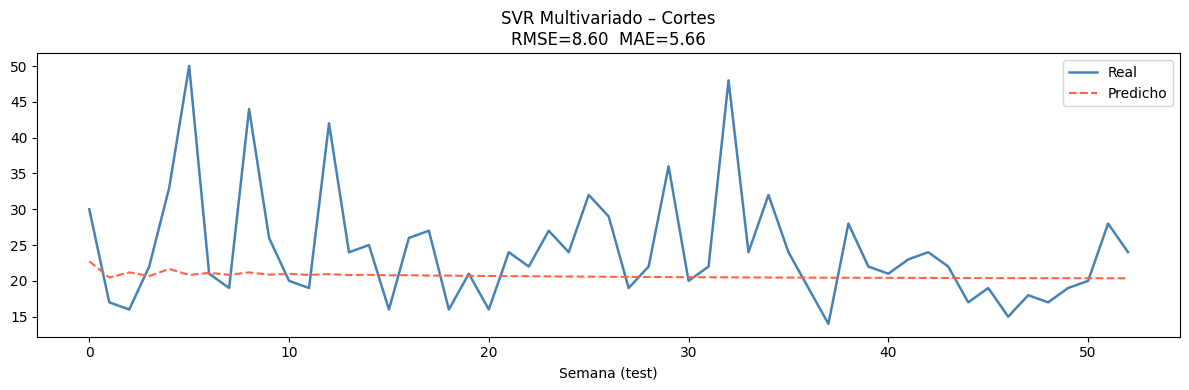

In [ ]:

y_train_c = df['Cortes'].values.astype(float)[:N_TRAIN]
y_train_t = df['Temp'].values.astype(float)[:N_TRAIN]
y_train_h = df['Hum'].values.astype(float)[:N_TRAIN]
y_test_c  = df['Cortes'].values.astype(float)[N_TRAIN:]

X_tr_m, y_tr_m = make_lags_multi(y_train_c, y_train_t, y_train_h, n_lags=N_LAGS)
N_FEAT = X_tr_m.shape[1]

scaler_Xm = StandardScaler()
scaler_ym = StandardScaler()
X_tr_ms   = scaler_Xm.fit_transform(X_tr_m)
y_tr_ms   = scaler_ym.fit_transform(y_tr_m.reshape(-1, 1)).ravel()

best_m = fit_svr(X_tr_ms, y_tr_ms)

seed_m = np.concatenate([
    y_train_c[-N_LAGS:], y_train_t[-N_LAGS:], y_train_h[-N_LAGS:]
])
seed_ms = scaler_Xm.transform(seed_m.reshape(1, -1))[0]
y_pred_m = predict_recursive_multi(best_m, seed_ms, N_TEST, scaler_ym, N_LAGS, N_FEAT)

rmse_m = float(np.sqrt(mean_squared_error(y_test_c, y_pred_m)))
mae_m  = float(mean_absolute_error(y_test_c, y_pred_m))
print(f"  RMSE={rmse_m:.4f}  MAE={mae_m:.4f}")

svr_results.append({
    'model' : 'SVR_Multi',
    'serie' : 'Cortes (Temp+Hum)',
    'date'  : test_df.index,
    'y_true': y_test_c,
    'y_pred': y_pred_m,
    'rmse'  : round(rmse_m, 4),
    'mae'   : round(mae_m, 4),
})

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y_test_c,  label='Real',     color='steelblue', lw=1.8)
ax.plot(y_pred_m,  label='Predicho', color='tomato',    lw=1.5, linestyle='--')
ax.set_title(f'SVR Multivariado – Cortes\nRMSE={rmse_m:.2f}  MAE={mae_m:.2f}')
ax.set_xlabel('Semana (test)')
ax.legend()
plt.tight_layout()
plt.savefig('svr_multivariado.png', dpi=120, bbox_inches='tight')
plt.show()


El modelo multivariado obtuvo RMSE=8.60 y MAE=5.66, resultado paradójicamente peor que el univariado (RMSE=7.98). Visualmente, la predicción colapsa aún más hacia una línea plana alrededor de 21 cortes, sin capturar ninguna de las fluctuaciones reales de la serie.

## 5. Comparación de performance out of sample del modelado Univariado vs Multivariado


  Univariado  → RMSE=7.9810  MAE=5.4937
  Multivariado→ RMSE=8.5993  MAE=5.6620

  ✓ Ganador: Univariado


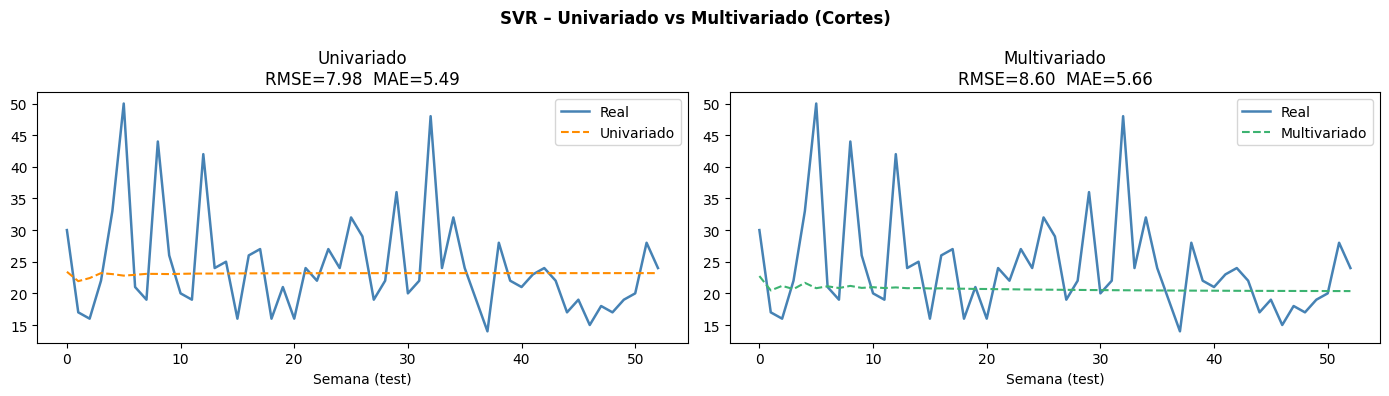

In [ ]:
r_uni   = svr_results[0]   # Cortes univariado
r_multi = svr_results[-1]  # Cortes multivariado

print(f"  Univariado  → RMSE={r_uni['rmse']:.4f}  MAE={r_uni['mae']:.4f}")
print(f"  Multivariado→ RMSE={r_multi['rmse']:.4f}  MAE={r_multi['mae']:.4f}")
ganador = 'Univariado' if r_uni['rmse'] <= r_multi['rmse'] else 'Multivariado'
print(f"\n  ✓ Ganador: {ganador}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('SVR – Univariado vs Multivariado (Cortes)', fontweight='bold')
for ax, (label, r, color) in zip(axes, [
    ('Univariado',   r_uni,   'darkorange'),
    ('Multivariado', r_multi, 'mediumseagreen'),
]):
    ax.plot(r['y_true'], label='Real',  color='steelblue', lw=1.8)
    ax.plot(r['y_pred'], label=label,   color=color,       lw=1.5, linestyle='--')
    ax.set_title(f'{label}\nRMSE={r["rmse"]:.2f}  MAE={r["mae"]:.2f}')
    ax.set_xlabel('Semana (test)')
    ax.legend()
plt.tight_layout()
plt.savefig('svr_uni_vs_multi.png', dpi=120, bbox_inches='tight')
plt.show()



Ambos modelos convergen en el mismo comportamiento: predicciones casi constantes alrededor de la media histórica de la serie, sin capacidad de anticipar fluctuaciones. La diferencia visual entre ambos gráficos es mínima, y las métricas confirman que el univariado (RMSE=7.98) supera al multivariado (RMSE=8.60).
En SVR las variables climáticas no solo no aportan sino que degradan levemente el desempeño. Esto refuerza la limitación estructural del modo recursivo con alta dimensionalidad mencionada anteriormente.


## 6.Guardado final


Guardado final: Se exportan las predicciones del conjunto de test (20% final) para cada serie: modelos univariados (Cortes, Temp, Hum) y el modelo multivariado (Cortes ~ Temp + Hum). Incluye valores reales (y_true), predicciones (y_pred) y métricas (RMSE, MAE). Los resultados corresponden a los modelos optimizados por Grid Search.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
BASE_PATH = "/content/drive/MyDrive/SDT/Resultados"
os.makedirs(BASE_PATH, exist_ok=True)

Mounted at /content/drive


In [ ]:
all_preds   = []
all_metrics = []

for r in svr_results:
    all_preds.append(pd.DataFrame({
        'model' : r['model'],
        'serie' : r['serie'],
        'date'  : r['date'],
        'y_true': r['y_true'],
        'y_pred': r['y_pred'],
    }))
    all_metrics.append({
        'model': r['model'],
        'serie': r['serie'],
        'rmse' : r['rmse'],
        'mae'  : r['mae'],
    })

pd.concat(all_preds).to_csv(
    f"{BASE_PATH}/predictions_SVR.csv", index=False)
pd.DataFrame(all_metrics).to_csv(
    f"{BASE_PATH}/metrics_SVR.csv", index=False)

print("\n✔ SVR guardado correctamente")
print(pd.DataFrame(all_metrics))


✔ SVR guardado correctamente
       model              serie     rmse      mae
0    SVR_Uni             Cortes   7.9810   5.4937
1    SVR_Uni               Temp   7.6638   6.2515
2    SVR_Uni                Hum  16.0349  14.0264
3  SVR_Multi  Cortes (Temp+Hum)   8.5993   5.6620
